In [1]:
!pip install emoji --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 24.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
import pandas as pd

data = pd.read_csv("/content/drive/MyDrive/Sentiment_Data.csv", encoding='ISO-8859-1')
print(data.info())
print(data['Sentiment'].value_counts())
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451332 entries, 0 to 451331
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Tweet      451331 non-null  object
 1   Sentiment  451332 non-null  object
dtypes: object(2)
memory usage: 6.9+ MB
None
Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos


In [8]:
import pandas as pd
import re
import emoji
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(data, test_size=0.3, stratify=data['Sentiment'], random_state=42)

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")
print("Train label distribution:\n", train_df['Sentiment'].value_counts(normalize=True))
print("Test label distribution:\n", test_df['Sentiment'].value_counts(normalize=True))


Train size: 315932, Test size: 135400
Train label distribution:
 Sentiment
Strong_Pos    0.517801
Neutral       0.170641
Mild_Pos      0.141812
Strong_Neg    0.094289
Mild_Neg      0.075456
Name: proportion, dtype: float64
Test label distribution:
 Sentiment
Strong_Pos    0.517799
Neutral       0.170643
Mild_Pos      0.141809
Strong_Neg    0.094291
Mild_Neg      0.075458
Name: proportion, dtype: float64


In [9]:
# Regex Cleaning
def regex_clean(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)       # Remove URLs
    text = re.sub(r'@\w+', '', text)                        # Remove mentions
    text = re.sub(r'#\w+', '', text)                        # Remove hashtags
    text = re.sub(r'[^\w\s]', '', text)                     # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()                # Remove extra spaces
    return text

# Emoji Handling
def handle_emojis(text):
    return emoji.demojize(text, delimiters=(" ", " "))

# Slang Replacement
slang_dict = {
    "idk": "i do not know", "lol": "laugh out loud", "omg": "oh my god",
    "brb": "be right back", "btw": "by the way", "ttyl": "talk to you later",
    "imo": "in my opinion", "fyi": "for your information", "smh": "shaking my head",
    "tbh": "to be honest", "lmao": "laughing my ass off", "rofl": "rolling on the floor laughing",
    "np": "no problem", "yw": "you are welcome", "bff": "best friends forever",
    "afaik": "as far as i know", "ikr": "i know right", "jk": "just kidding",
    "nvm": "never mind", "omw": "on my way", "thx": "thanks", "ty": "thank you",
    "gr8": "great", "plz": "please", "wtf": "what the fuck", "wth": "what the hell",
    "fomo": "fear of missing out", "irl": "in real life", "tmi": "too much information",
    "cya": "see you", "cu": "see you", "dm": "direct message", "ftw": "for the win",
    "ftl": "for the loss", "gg": "good game", "gl": "good luck", "wyd": "what are you doing",
    "yolo": "you only live once"
}

def replace_slangs(text):
    words = text.split()
    return " ".join([slang_dict.get(w, w) for w in words])

# Negation Handling
def negation_handling(text):
    negation_words = {'not', 'no', 'never', "n't"}
    tokens = text.split()
    new_tokens = []
    negate = False
    count = 0
    for token in tokens:
        if token in negation_words:
            negate = True
            count = 0
            new_tokens.append(token)
        elif negate:
            new_tokens.append("not_" + token)
            count += 1
            if count >= 5:
                negate = False
        else:
            new_tokens.append(token)
    return " ".join(new_tokens)

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = regex_clean(text)
    text = handle_emojis(text)
    text = replace_slangs(text)
    text = negation_handling(text)
    return text

# Label Mapping Function
def map_sentiment(label):
    mapping = {
        'Strong_Pos': 'Positive',
        'Mild_Pos': 'Positive',
        'Neutral': 'Neutral',
        'Mild_Neg': 'Negative',
        'Strong_Neg': 'Negative'
    }
    return mapping.get(label, label)

In [10]:
train_df['cleaned'] = train_df['Tweet'].fillna('').astype(str).apply(preprocess_text)
test_df['cleaned'] = test_df['Tweet'].fillna('').astype(str).apply(preprocess_text)

# Map labels to 3 classes
train_df['Sentiment'] = train_df['Sentiment'].apply(map_sentiment)
test_df['Sentiment'] = test_df['Sentiment'].apply(map_sentiment)

# Confirm mapping worked
print(train_df['Sentiment'].value_counts())
print(test_df['Sentiment'].value_counts())

Sentiment
Positive    208393
Neutral      53911
Negative     53628
Name: count, dtype: int64
Sentiment
Positive    89311
Neutral     23105
Negative    22984
Name: count, dtype: int64


In [11]:
print(train_df[['Tweet', 'cleaned', 'Sentiment']].head())
print(test_df[['Tweet', 'cleaned', 'Sentiment']].head())

# Save if needed
train_df.to_csv('train_preprocessed.csv', index=False)
test_df.to_csv('test_preprocessed.csv', index=False)


                                                    Tweet  \
127180  @sheepkingjb @CarymaRules Iâve seen this guy...   
92417   @RobertFife To Robert fife . This had nothing ...   
351847  This thread\n\n#ThanksJoeRogan #FreedomConvoy2...   
188891  Patriots line the route to show support for th...   
124760  Oath Keepers, anti-democracy activists, and ot...   

                                                  cleaned Sentiment  
127180  iâve seen this guy in a video wearing a kilt a...  Positive  
92417   to robert fife this had nothing to do withthe ...  Positive  
351847                                        this thread   Neutral  
188891  patriots line the route to show support for th...  Positive  
124760  oath keepers antidemocracy activists and other...   Neutral  
                                                    Tweet  \
155192  Ottawa Police chief admits no firearms discove...   
85987   @DebbieSammit @Bunnyhug123 @JeffreyLuscombe @P...   
87607   @roulinski @CPC_HQ @Pi

In [12]:
import pandas as pd

train_df = pd.read_csv('train_preprocessed.csv')
test_df = pd.read_csv('test_preprocessed.csv')

print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

Train samples: 315932, Test samples: 135400


In [13]:
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())


Train columns: ['Tweet', 'Sentiment', 'cleaned']
Test columns: ['Tweet', 'Sentiment', 'cleaned']


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import tensorflow as tf


In [15]:
train_df = pd.read_csv('train_preprocessed.csv')
test_df = pd.read_csv('test_preprocessed.csv')

print("Train samples:", len(train_df))
print("Test samples:", len(test_df))
train_df.head()


Train samples: 315932
Test samples: 135400


,Tweet,Sentiment,cleaned
0,@sheepkingjb @CarymaRules Iâve seen this guy...,Positive,iâve seen this guy in a video wearing a kilt a...
1,@RobertFife To Robert fife . This had nothing ...,Positive,to robert fife this had nothing to do withthe ...
2,This thread\n\n#ThanksJoeRogan #FreedomConvoy2...,Neutral,this thread
3,Patriots line the route to show support for th...,Positive,patriots line the route to show support for th...
4,"Oath Keepers, anti-democracy activists, and ot...",Neutral,oath keepers antidemocracy activists and other...


In [16]:
le = LabelEncoder()
train_df['label_enc'] = le.fit_transform(train_df['Sentiment'])
test_df['label_enc'] = le.transform(test_df['Sentiment'])

num_classes = len(le.classes_)
print("Classes:", le.classes_)

Classes: ['Negative' 'Neutral' 'Positive']


In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 64
MAX_VOCAB = 20000

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['cleaned'].astype(str).fillna(''))

X_train = pad_sequences(tokenizer.texts_to_sequences(train_df['cleaned'].astype(str).fillna('')), maxlen=MAX_LEN)
X_test = pad_sequences(tokenizer.texts_to_sequences(test_df['cleaned'].astype(str).fillna('')), maxlen=MAX_LEN)

y_train = to_categorical(train_df['label_enc'], num_classes)
y_test = to_categorical(test_df['label_enc'], num_classes)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense

EMBED_DIM = 128
LSTM_UNITS = 64
DROPOUT = 0.3

model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=False)),
    Dropout(DROPOUT),
    Dense(num_classes, activation='softmax')
])


model.build(input_shape=(None, MAX_LEN))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 64, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,203 (10.14 MB)

 Trainable params: 2,659,203 (10.14 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
import time
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-6, verbose=1)

start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

end_time = time.time()
train_time = end_time - start_time
print(f"\n Training Time: {train_time:.2f} seconds")


Epoch 1/30
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.8112 - loss: 0.4926 - val_accuracy: 0.8979 - val_loss: 0.2903 - learning_rate: 0.0010
Epoch 2/30
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - accuracy: 0.9112 - loss: 0.2512 - val_accuracy: 0.9131 - val_loss: 0.2532 - learning_rate: 0.0010
Epoch 3/30
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9306 - loss: 0.2000 - val_accuracy: 0.9147 - val_loss: 0.2483 - learning_rate: 0.0010
Epoch 4/30
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - accuracy: 0.9419 - loss: 0.1699 - val_accuracy: 0.9163 - val_loss: 0.2620 - learning_rate: 0.0010
Epoch 5/30
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9527 - loss: 0.1417
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 45s 15ms/step - accuracy: 0.9527 - loss: 0.1417 - val_accuracy: 0.9109 - val_loss: 0.2834 - learning_rate: 0.0010
Epoch 6/30
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 45s 17ms/step - accuracy

In [20]:
# Epochs run (1-indexed)
epochs_run = len(history.history['loss'])
print(f"Early stopping occurred at epoch: {epochs_run}")

Early stopping occurred at epoch: 6


In [21]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")


Test Accuracy: 0.9161


4232/4232 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step
              precision    recall  f1-score   support

    Negative       0.88      0.85      0.87     22984
     Neutral       0.85      0.76      0.80     23105
    Positive       0.94      0.97      0.96     89311

    accuracy                           0.92    135400
   macro avg       0.89      0.86      0.88    135400
weighted avg       0.91      0.92      0.91    135400



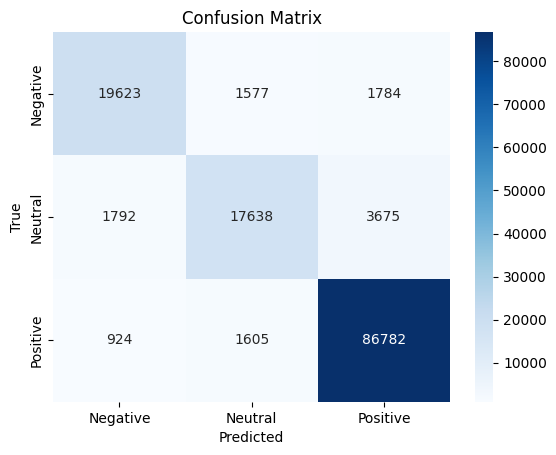

In [22]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Confusion matrix
conf_mat = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [23]:
if num_classes == 3:
    auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
    print("Multi-class AUC (OVR):", auc)


Multi-class AUC (OVR): 0.9747678267725494


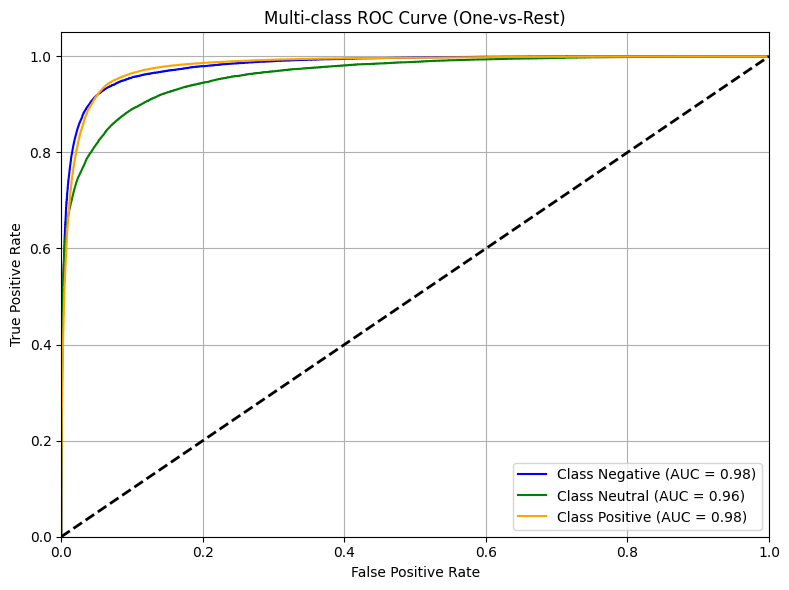

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'orange']
for i, label in enumerate(le.classes_):
    plt.plot(fpr[i], tpr[i], color=colors[i],
             label=f'Class {label} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Hyperparameter Tuning

In [25]:
!pip install -q keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 9.4 MB/s eta 0:00:00


In [26]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense

def build_model(hp):
    model = Sequential()

    # Choose between 64, 128, or 256 dimensions for embedding layer
    model.add(Embedding(
        input_dim=MAX_VOCAB,
        output_dim=hp.Choice('embed_dim', [64, 128, 256]),
        input_length=MAX_LEN
    ))

    # LSTM units: try 32, 64, 96, or 128
    model.add(Bidirectional(LSTM(
        units=hp.Int('lstm_units', min_value=32, max_value=128, step=32),
        return_sequences=False
    )))

    # Dropout: test values between 0.2 and 0.5
    model.add(Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [27]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',         # what we want to optimize
    max_trials=10,                    # try 10 different combinations
    executions_per_trial=1,          # train each model once
    directory='bilstm_tuner',
    project_name='nlp_sentiment'
)

In [28]:
tuner.search(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)


Trial 10 Complete [00h 03m 47s]
val_accuracy: 0.9194467067718506

Best val_accuracy So Far: 0.9210293292999268
Total elapsed time: 00h 38m 36s


In [29]:
best_hps = tuner.get_best_hyperparameters(1)[0]

print(f"Best embed_dim: {best_hps.get('embed_dim')}")
print(f"Best lstm_units: {best_hps.get('lstm_units')}")
print(f"Best dropout: {best_hps.get('dropout')}")



Best embed_dim: 256
Best lstm_units: 128
Best dropout: 0.4


In [30]:
# Rebuild model using best parameters
best_model = tuner.hypermodel.build(best_hps)

# Train final model
history = best_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 46s 20ms/step - accuracy: 0.8193 - loss: 0.4725 - val_accuracy: 0.9099 - val_loss: 0.2571 - learning_rate: 0.0010
Epoch 2/30
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 83s 20ms/step - accuracy: 0.9210 - loss: 0.2264 - val_accuracy: 0.9210 - val_loss: 0.2322 - learning_rate: 0.0010
Epoch 3/30
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 81s 19ms/step - accuracy: 0.9385 - loss: 0.1793 - val_accuracy: 0.9210 - val_loss: 0.2406 - learning_rate: 0.0010
Epoch 4/30
2219/2222 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9493 - loss: 0.1472
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - accuracy: 0.9493 - loss: 0.1472 - val_accuracy: 0.9201 - val_loss: 0.2468 - learning_rate: 0.0010
Epoch 5/30
2222/2222 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - accuracy: 0.9633 - loss: 0.1084 - val_accuracy: 0.9197 - val_loss: 0.2862 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end o